In [1]:
pip install requests beautifulsoup4 pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


# Import Necessary Libraries

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All Libraries Imported Successfully!")

✅ All Libraries Imported Successfully!


# WEB SCRAPING DATA

In [7]:
# Yearly pages have MORE columns!
# Rank, Title, Studio, Total Gross, Tickets Sold + we add Year, Decade, etc.

url = "https://www.boxofficemojo.com/year/2023/"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}

response2 = requests.get(url, headers=headers)
soup2     = BeautifulSoup(response2.content, "html.parser")
table2    = soup2.find("table")

# Check columns
headers_row = table2.find_all("th")
columns     = [col.text.strip() for col in headers_row]

print(f"Status Code   : {response2.status_code}")
print(f"Columns Found : {len(columns)}")
print(f"Column Names  : {columns}")

rows = table2.find_all("tr")
print(f"Total Rows    : {len(rows)}")
print(f"\nFirst Row Sample:")
print(rows[1].text.strip())

Status Code   : 200
Columns Found : 11
Column Names  : ['Rank', 'Release', 'Genre', 'Budget', 'Running Time', 'Gross', 'Theaters', 'Total Gross', 'Release Date', 'Distributor', 'Estimated']
Total Rows    : 201

First Row Sample:
1Barbie---$636,225,9834,337$636,238,421Jul 21Warner Bros.

false


In [8]:
# Scraping years 2015 to 2023 = 9 years × ~200 movies = 1800+ rows!

def scrape_boxoffice():
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}
    all_movies = []
    years = list(range(2015, 2024))  # 2015 to 2023

    for year in years:
        url = f"https://www.boxofficemojo.com/year/{year}/"
        print(f"⏳ Scraping year {year}...")

        response = requests.get(url, headers=headers)

        if response.status_code != 200:
            print(f"   ❌ Failed — Status: {response.status_code}")
            continue

        soup  = BeautifulSoup(response.content, "html.parser")
        table = soup.find("table")

        if table:
            rows = table.find_all("tr")[1:]  # Skip header
            for row in rows:
                cols = row.find_all("td")
                if len(cols) >= 10:
                    movie = {
                        "Rank"         : cols[0].text.strip(),
                        "Title"        : cols[1].text.strip(),
                        "Genre"        : cols[2].text.strip(),
                        "Budget"       : cols[3].text.strip(),
                        "Running_Time" : cols[4].text.strip(),
                        "Gross"        : cols[5].text.strip(),
                        "Theaters"     : cols[6].text.strip(),
                        "Total_Gross"  : cols[7].text.strip(),
                        "Release_Date" : cols[8].text.strip(),
                        "Distributor"  : cols[9].text.strip(),
                        "Year"         : year
                    }
                    all_movies.append(movie)

        print(f"   ✅ Collected so far: {len(all_movies)} movies")

    return all_movies

# Run scraper
movies_data = scrape_boxoffice()
print(f"\n🎬 Total Movies Scraped: {len(movies_data)}")

⏳ Scraping year 2015...
   ✅ Collected so far: 200 movies
⏳ Scraping year 2016...
   ✅ Collected so far: 400 movies
⏳ Scraping year 2017...
   ✅ Collected so far: 600 movies
⏳ Scraping year 2018...
   ✅ Collected so far: 800 movies
⏳ Scraping year 2019...
   ✅ Collected so far: 1000 movies
⏳ Scraping year 2020...
   ✅ Collected so far: 1200 movies
⏳ Scraping year 2021...
   ✅ Collected so far: 1400 movies
⏳ Scraping year 2022...
   ✅ Collected so far: 1600 movies
⏳ Scraping year 2023...
   ✅ Collected so far: 1800 movies

🎬 Total Movies Scraped: 1800


# Create DataFrame

In [9]:
df = pd.DataFrame(movies_data)
print("✅ DataFrame Created!")
print(f"\nShape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

✅ DataFrame Created!

Shape  : (1800, 11)
Columns: ['Rank', 'Title', 'Genre', 'Budget', 'Running_Time', 'Gross', 'Theaters', 'Total_Gross', 'Release_Date', 'Distributor', 'Year']


,Rank,Title,Genre,Budget,Running_Time,Gross,Theaters,Total_Gross,Release_Date,Distributor,Year
0,1,Jurassic World,-,-,-,"$652,270,625","4,291","$652,270,625",Jun 12,Universal Pictures,2015
1,2,Star Wars: Episode VII - The Force Awakens,-,-,-,"$651,967,269","4,134","$936,662,225",Dec 18,Walt Disney Studios Motion Pictures,2015
2,3,Avengers: Age of Ultron,-,-,-,"$459,005,868","4,276","$459,005,868",May 1,Walt Disney Studios Motion Pictures,2015
3,4,Inside Out,-,-,-,"$356,461,711","4,158","$356,461,711",Jun 19,Walt Disney Studios Motion Pictures,2015
4,5,Furious 7,-,-,-,"$353,007,020","4,022","$353,007,020",Apr 3,Universal Pictures,2015


# CONVERT TO CSV FILE

In [10]:
df.to_csv("boxoffice_raw.csv", index=False)
print("✅ Raw data saved to: boxoffice_raw.csv")

✅ Raw data saved to: boxoffice_raw.csv


# DATASET UNDERSTANDING

In [11]:
df = pd.read_csv("boxoffice_raw.csv")
print("="*50)
print("📊 DATASET OVERVIEW")
print("="*50)
print(f"Number of Features   (Columns) : {df.shape[1]}")
print(f"Number of Observations  (Rows) : {df.shape[0]}")

📊 DATASET OVERVIEW
Number of Features   (Columns) : 11
Number of Observations  (Rows) : 1800


# DATA TYPES VALIDATION

In [12]:
print("Data Type of Each Column:")
print(df.dtypes)

Data Type of Each Column:
Rank            int64
Title             str
Genre             str
Budget            str
Running_Time      str
Gross             str
Theaters          str
Total_Gross       str
Release_Date      str
Distributor       str
Year            int64
dtype: object


# DATA CLEANING

In [27]:
cols = ["Budget", "Gross", "Total_Gross"]

for col in cols:
    df[col] = df[col].astype(str).str.replace(r'[\$,]', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [28]:
df["Running_Time"] = df["Running_Time"].astype(str).str.extract(r'(\d+)')
df["Running_Time"] = pd.to_numeric(df["Running_Time"], errors='coerce')

In [29]:
df["Theaters"] = df["Theaters"].astype(str).str.replace(',', '', regex=True)
df["Theaters"] = pd.to_numeric(df["Theaters"], errors='coerce')

In [30]:
df["Release_Date"] = pd.to_datetime(df["Release_Date"], errors='coerce')

In [31]:
print(df.dtypes)

Rank                     int64
Title                      str
Genre                      str
Budget                 float64
Running_Time           float64
Gross                  float64
Theaters               float64
Total_Gross            float64
Release_Date    datetime64[us]
Distributor                str
Year                     int64
dtype: object


In [35]:
df[["Running_Time", "Theaters"]].isnull().sum()

Running_Time    1800
Theaters           8
dtype: int64

In [36]:
df["Running_Time"].fillna(df["Running_Time"].median(), inplace=True)

0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
        ..
1795   NaN
1796   NaN
1797   NaN
1798   NaN
1799   NaN
Name: Running_Time, Length: 1800, dtype: float64

In [37]:
df.drop(columns=["Running_Time"], inplace=True)

In [41]:
# Handle Theaters (8 missing values)
df.dropna(subset=["Theaters"], inplace=True)

# Convert to integer
df["Theaters"] = df["Theaters"].astype(int)

# Convert categorical columns
df["Title"] = df["Title"].astype("string")
df["Genre"] = df["Genre"].astype("string")
df["Distributor"] = df["Distributor"].astype("string")

In [42]:
print(df.shape)
print(df.dtypes)
df.isnull().sum()

(1792, 10)
Rank                     int64
Title                   string
Genre                   string
Budget                 float64
Gross                  float64
Theaters                 int64
Total_Gross            float64
Release_Date    datetime64[us]
Distributor             string
Year                     int64
dtype: object


Rank               0
Title              0
Genre              0
Budget          1792
Gross              0
Theaters           0
Total_Gross        0
Release_Date       2
Distributor        0
Year               0
dtype: int64

In [46]:
list(df.columns)

['Rank',
 'Title',
 'Genre',
 'Gross',
 'Theaters',
 'Total_Gross',
 'Release_Date',
 'Distributor',
 'Year']

In [49]:
df.head(10)

,Rank,Title,Genre,Gross,Theaters,Total_Gross,Release_Date,Distributor,Year
0,1,Jurassic World,-,652270625.0,4291,652270625.0,1-06-12,Universal Pictures,2015
1,2,Star Wars: Episode VII - The Force Awakens,-,651967269.0,4134,936662225.0,1-12-18,Walt Disney Studios Motion Pictures,2015
2,3,Avengers: Age of Ultron,-,459005868.0,4276,459005868.0,1-05-01,Walt Disney Studios Motion Pictures,2015
3,4,Inside Out,-,356461711.0,4158,356461711.0,1-06-19,Walt Disney Studios Motion Pictures,2015
4,5,Furious 7,-,353007020.0,4022,353007020.0,1-04-03,Universal Pictures,2015
5,6,American Sniper,-,348797073.0,3885,350126372.0,1-12-25,Warner Bros.,2015
6,7,Minions,-,336045770.0,4311,336045770.0,1-07-10,Universal Pictures,2015
7,8,The Hunger Games: Mockingjay - Part 2,-,269569121.0,4175,281723902.0,1-11-20,Lionsgate,2015
8,9,The Martian,-,225345353.0,3854,228433663.0,1-10-02,20th Century Fox,2015
9,10,Cinderella,-,201151353.0,3848,201151353.0,1-03-13,Walt Disney Studios Motion Pictures,2015


In [50]:
df.tail(5)

,Rank,Title,Genre,Gross,Theaters,Total_Gross,Release_Date,Distributor,Year
1795,196,Emily,-,1097067.0,579,1097067.0,1-02-17,Bleecker Street Media,2023
1796,197,Knights of the Zodiac,-,1090155.0,588,1090155.0,1-05-12,-,2023
1797,198,Broker,-,1001892.0,271,1046899.0,1-12-23,Neon,2023
1798,199,Showing Up,-,972074.0,115,754483.0,1-04-07,A24,2023
1799,200,Inside,-,918415.0,357,918415.0,1-03-17,Focus Features,2023


In [52]:
df.info()

<class 'pandas.DataFrame'>
Index: 1790 entries, 0 to 1799
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Rank          1790 non-null   int64         
 1   Title         1790 non-null   string        
 2   Genre         1790 non-null   string        
 3   Gross         1790 non-null   float64       
 4   Theaters      1790 non-null   int64         
 5   Total_Gross   1790 non-null   float64       
 6   Release_Date  1790 non-null   datetime64[us]
 7   Distributor   1790 non-null   string        
 8   Year          1790 non-null   int64         
dtypes: datetime64[us](1), float64(2), int64(3), string(3)
memory usage: 139.8 KB


In [55]:
df["Release_Date"] = pd.to_datetime(df["Release_Date"], errors='coerce')

In [95]:
df.drop(columns=["Genre"], inplace=True, errors='ignore')

In [89]:
df.columns

Index(['Rank', 'Title', 'Gross', 'Theaters', 'Total_Gross', 'Distributor',
       'Year'],
      dtype='str')

# SUMMARY OF STATISTICS

In [58]:
df.describe()

,Rank,Gross,Theaters,Total_Gross,Year
count,1790.000000,1.790000e+03,1790.000000,1.790000e+03,1790.000000
mean,100.291620,4.389159e+07,2166.439106,5.472761e+07,2018.987151
std,57.760331,8.523250e+07,1378.553326,1.021467e+08,2.582859
min,1.000000,1.535040e+05,5.000000,4.384600e+04,2015.000000
25%,50.000000,3.400084e+06,794.750000,4.011442e+06,2017.000000
50%,100.000000,1.263891e+07,2327.000000,1.731801e+07,2019.000000
75%,150.000000,4.541118e+07,3379.750000,5.684680e+07,2021.000000
max,200.000000,8.583730e+08,4802.000000,9.366622e+08,2023.000000


✅ 📊 Interpretation of Your Summary

🔹 1. Rank

Mean ≈ 100
Range: 1 to 200

👉 Insight:

Dataset is evenly distributed across ranks
Rank is more of an identifier, not useful for prediction
🔹 2. Gross (Domestic Revenue)
Mean ≈ 43.8 Million
Median ≈ 12.6 Million
Max ≈ 858 Million

👉 Analysis:

Mean >> Median → highly right-skewed

👉 Insight:

Few blockbuster movies generate extremely high revenue
Majority of movies earn relatively less
🔹 3. Total_Gross (Worldwide Revenue)
Mean ≈ 54.7 Million
Max ≈ 936 Million

👉 Analysis:

Higher than domestic gross → expected

👉 Insight:

International markets significantly contribute to revenue
Strong relationship with domestic gross
🔹 4. Theaters
Mean ≈ 2166 theaters
Median ≈ 2327
Max ≈ 4802

👉 Analysis:

Wide spread of values

👉 Insight:

Movies released in more theaters tend to earn higher revenue
Distribution reach is a key success factor
🔹 5. Year
Range: 2015 → 2023
Mean ≈ 2019

👉 Insight:

Covers multiple years → suitable for trend analysis
Allows comparison of industry performance over time
🔥 Key Business Insights (Write in Notebook)



✔ Insight 1

Revenue distribution is highly skewed, indicating that a small number of movies dominate total earnings.

✔ Insight 2

Total gross revenue is consistently higher than domestic gross, showing the importance of international markets.

✔ Insight 3

The number of theaters has a strong influence on movie revenue, highlighting the role of distribution scale.

✔ Insight 4

Most movies earn below the average, indicating a competitive and uneven market.

✔ Insight 5

The dataset spans multiple years, enabling analysis of trends in the film industry.

# EXPLORATORY DATA ANALYSIS

# Univariate Analysis

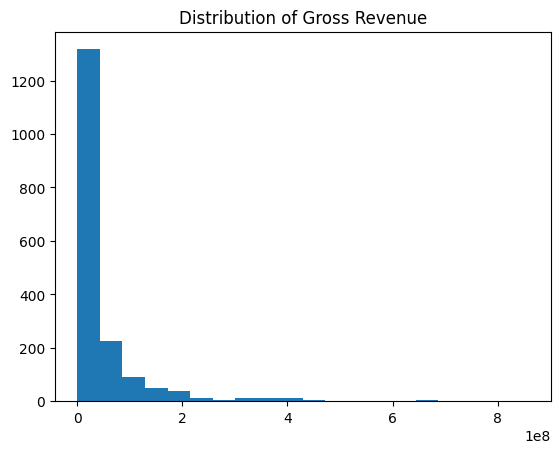

In [61]:
#Numerical Variables
  
#Gross Distribution
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["Gross"], bins=20)
plt.title("Distribution of Gross Revenue")
plt.show()

**✍️ Interpretation:**

**✍️ Observation 1:**

> The distribution is highly right-skewed, where most movies have lower gross values.>

**✍️ Observation 2:**

> A small number of movies have very high gross revenue, creating a long tail on the right side.

**🧠 Meaning**

**👉 Most movies:**

> Earn less revenue

**👉 Few movies:**

> Become blockbusters

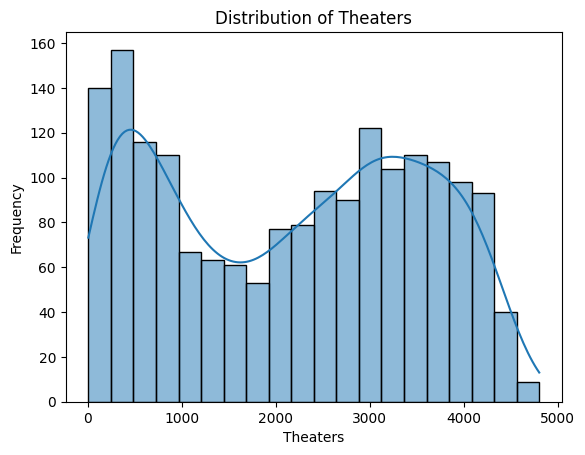

In [77]:
# Theaters Distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.histplot(df["Theaters"], bins=20, kde=True)
plt.title("Distribution of Theaters")
plt.xlabel("Theaters")
plt.ylabel("Frequency")
plt.show()

**🎯Interpretation**

**✍️ Observation 1:**

> The distribution of theaters is spread across a wide range, indicating that movies are released in both limited and large numbers of theaters.

**✍️ Observation 2:**

> There is a higher concentration of movies in the mid-range of theater counts, with fewer movies at extremely low or extremely high values.

**🧠 Meaning:**

**👉 Most movies:**

> Release in moderate number of theaters

**👉 Few movies:**

> Get very wide releases (blockbusters)

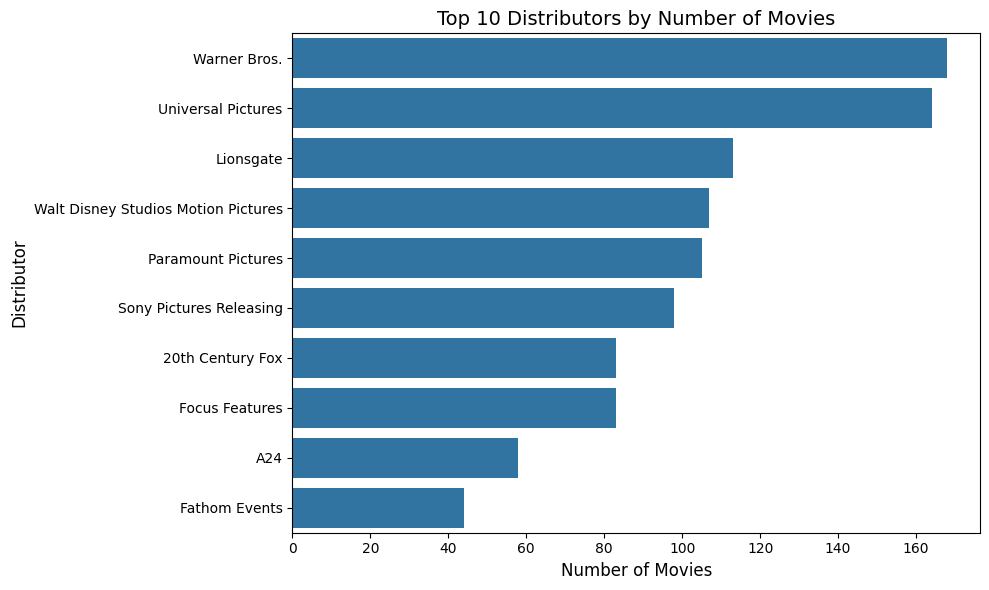

In [96]:
#📊 Categorical Variables

#Distributor Graph
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

top_distributors = df["Distributor"].value_counts().head(10)

sns.barplot(
    x=top_distributors.values,
    y=top_distributors.index
)

plt.title("Top 10 Distributors by Number of Movies", fontsize=14)
plt.xlabel("Number of Movies", fontsize=12)
plt.ylabel("Distributor", fontsize=12)

plt.tight_layout()
plt.show()


**Interpretation:**

**✍️ Observation 1:**

> A few distributors have a significantly higher number of movie releases, indicating dominance in the industry.

**✍️ Observation 2:**

> Most distributors have relatively fewer releases, showing that movie distribution is concentrated among a small number of major companies.

**🧠 Insight**

**👉 Major Distributors:**

Release a large number of movies

Hold a significant share of the market

**👉 Smaller Distributors:**

Release fewer movies

Have limited market presence

# Bivariate Analysis

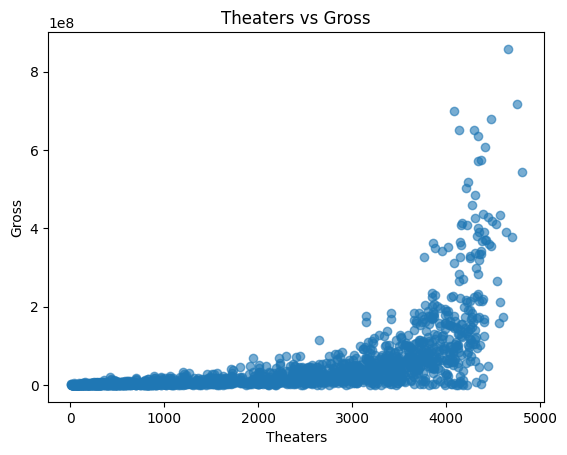

In [81]:
#🎯 Theaters vs Gross
plt.scatter(df["Theaters"], df["Gross"], alpha=0.6)
plt.xlabel("Theaters")
plt.ylabel("Gross")
plt.title("Theaters vs Gross")
plt.show()

**Interpretation:**

**✍️ Observation 1:**

> There is a positive relationship between the number of theatres and gross revenue.

> 👉 Movies released in more theatres generally earn higher revenue.

**✍️ Observation 2:**

> Points are widely scattered, not forming a perfect line.

> 👉 This means:

> Theatres alone do NOT decide success
Other factors (story, marketing, ratings) also matter

**✍️ Observation 3:**

> Some points may show:

> High theatres but low gross
> Low theatres but decent gross

> 👉 These are outliers/exceptions

**🧠 Meaning**

✔ Wider release → higher reach → higher revenue (trend)

❌ But not guaranteed → success depends on multiple factors

**🎯 Conclusion**

> 👉 Theatres positively influence Gross, but correlation is moderate (not strong)

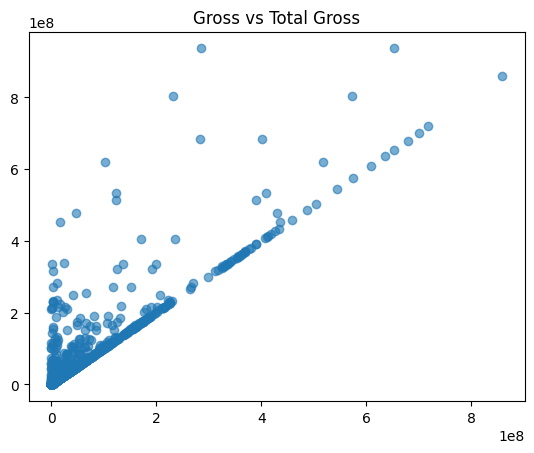

In [82]:
#🎯 Gross vs Total Gross
plt.scatter(df["Gross"], df["Total_Gross"], alpha=0.6)
plt.title("Gross vs Total Gross")
plt.show()

**📊 Interpretation**

**✔ Strong Positive Correlation**

> As Gross ↑ → Total_Gross ↑

**✔ Dense Cluster**

> Many movies grouped in mid-range earnings

**✔ Linear Pattern**

> Almost straight-line trend → strong relationship

**🧠 Critical Insight:**

> 👉 This relationship is inherently strong because:

**Total_Gross includes Gross**

> So:

> Not an independent relationship

> Not ideal for deep analysis:**



In [86]:
df.columns

Index(['Rank', 'Title', 'Gross', 'Theaters', 'Total_Gross', 'Distributor',
       'Year'],
      dtype='str')

# Multivariate Analysis

In [73]:
#Use Year for Multivariate Analysis - GROUP BY
year_mean = df.groupby("Year")["Total_Gross"].mean()
print(year_mean)

Year
2015    6.598460e+07
2016    6.775170e+07
2017    6.765387e+07
2018    7.060714e+07
2019    6.792963e+07
2020    2.549975e+07
2021    2.590282e+07
2022    4.645502e+07
2023    5.380121e+07
Name: Total_Gross, dtype: float64


**✍️ Observation 1:**

> From 2015 to 2019, the average total gross remained stable between approximately 65M and 70M, indicating consistent performance in the movie industry during this period.

**✍️ Observation 2:**

> In 2020 and 2021, there was a sharp decline in average total gross to around 25M, showing a significant drop compared to previous years.

**✍️ Observation 3:**

> After 2021, the average total gross began to recover, reaching around 46M in 2022 and 53M in 2023, indicating a gradual improvement in revenue.

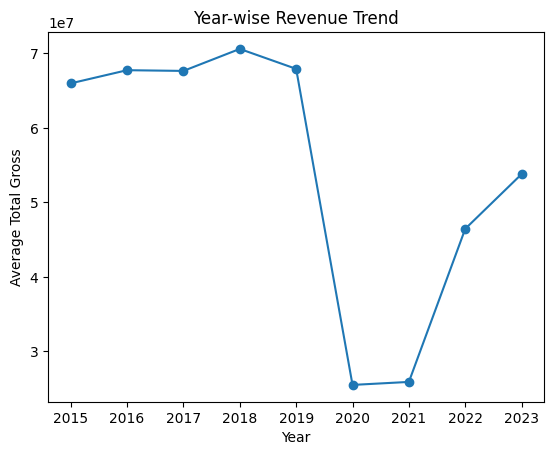

In [74]:
df.groupby("Year")["Total_Gross"].mean().plot(marker='o')
plt.title("Year-wise Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Average Total Gross")
plt.show()

**✍️ Observation from Graph:**

> The graph shows a relatively stable trend from 2015 to 2019, where the values remain almost flat.

**✍️ Observation from Graph:**

> There is a sharp drop around 2020, followed by a gradual upward trend after 2021, indicating recovery.

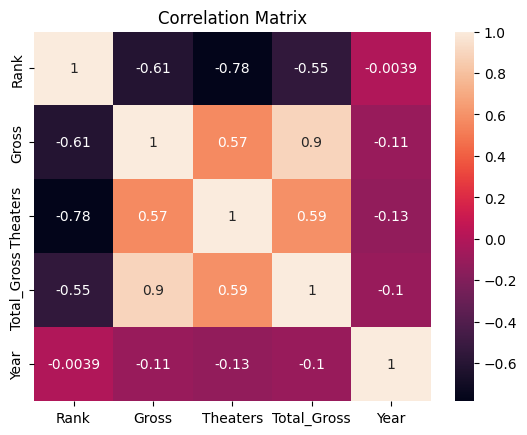

In [75]:
#Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

**✍️ Observation 1 (Strong Relationship):**

> There is a strong positive correlation between Gross and Total_Gross, meaning movies that earn high domestic revenue also tend to earn high total revenue.

**✍️ Observation 2 (Moderate Relationship):**

> There is a moderate positive relationship between Theaters and Gross, indicating that movies released in more theaters generally earn higher revenue.

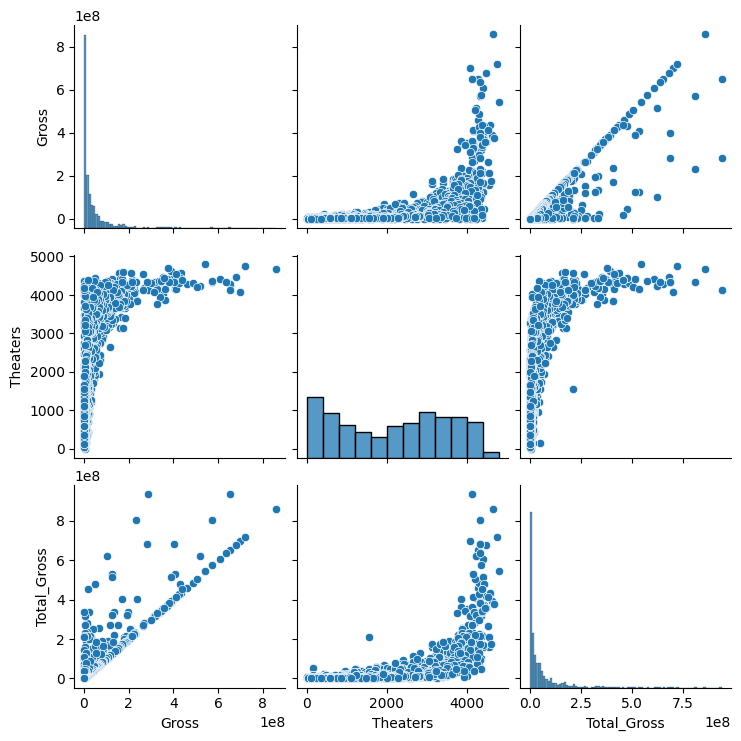

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df[["Gross", "Theaters", "Total_Gross"]])
plt.show()

# Final Interpretations

**📊 Interpretation**

**✍️ Observation 1:**

> There is a strong positive relationship between Gross and Total_Gross

→ Points form a near straight-line pattern

**✍️ Observation 2:**

> There is a moderate positive relationship between Theatres and Gross

→ As theatres increase, gross tends to increase

**✍️ Observation 3:**

> Theatres vs Total_Gross shows a weaker but positive trend

→ Wider release helps, but not the only factor

**✍️ Observation 4 (Diagonal plots):**

> Distributions show right-skewness
> 
→ Most movies earn lower revenue, few earn very high



**✍️ Interpretation 1 (Revenue Distribution)**

> The distribution of movie gross revenue is highly right-skewed, indicating that most movies earn relatively low revenue, while a small number of movies generate extremely high earnings.

**✍️ Interpretation 2 (Theatres vs Gross)**

> There is a moderate positive relationship between number of theaters and gross revenue, showing that wider movie releases generally lead to higher earnings, but do not guarantee success.

**✍️ Interpretation 3 (Gross vs Total Gross)**

> A strong positive linear relationship exists between Gross and Total_Gross, indicating that movies with strong initial performance tend to achieve high overall revenue.

**✍️ Interpretation 4 (Year-wise Trend)**

> The analysis shows stable revenue trends from 2015 to 2019, followed by a significant drop in 2020–2021 and a gradual recovery in subsequent years.

**✍️ Interpretation 5 (Distributor Analysis)**

> The distributor analysis reveals that a few major distributors dominate the market, releasing a significantly higher number of movies compared to others.

**✍️ Interpretation 6 (Pairplot Insight)**

> The pairplot confirms:

> Strong correlation between revenue variables

> Moderate influence of theatres on earnings

> Skewed distribution of financial variables

**✍️ Interpretation 7 (Data Limitation)**

> Certain variables, such as Genre and Budget, were excluded due to unavailability or inconsistency in the dataset, limiting some aspects of categorical and financial analysis.

# ✅ 🔹 FINAL CONCLUSION

> The distribution of movie revenue is highly right-skewed, where a small number of movies generate very high earnings while most movies earn relatively less.

> There is a moderate positive relationship between the number of theatres and gross revenue, indicating that wider releases generally contribute to higher earnings but do not guarantee success.

> A strong positive correlation exists between Gross and Total_Gross, showing that movies with strong initial performance tend to achieve higher overall revenue.

> The year-wise analysis shows stable performance from 2015 to 2019, followed by a significant decline in 2020–2021, and a gradual recovery in later years.

> The distributor analysis indicates that a few major distributors dominate the market by releasing a larger number of movies.

> The pairplot visualisation confirms the relationships between numerical variables, including strong revenue correlations and moderate influence of theatre count.

> Certain variables, such as Genre and Budget, were excluded due to unavailability or inconsistency in the dataset, which limited some aspects of the analysis.

**🔎 Summary** 

> Overall, the analysis shows that movie success is influenced by distribution scale and early performance, while also being unevenly distributed and affected by external factors.

# Project Flowchart: 
# Web Scraping → EDA → Insights

START
  ↓
Select Website
(Box Office Mojo - Year-wise Data)
  ↓
Web Scraping
- Extract: Rank, Title, Gross, Theaters, Total_Gross, Distributor, Year
  ↓
Create DataFrame
(pandas DataFrame creation)
  ↓
Data Cleaning
- Remove symbols ($, ,)
- Convert data types (int, float, datetime)
- Handle missing values
  ↓
❗ Data Issues Identified
- Genre → invalid ("-") → DROPPED
- Budget → missing → DROPPED
  ↓
Final Dataset
['Rank', 'Title', 'Gross', 'Theaters', 'Total_Gross', 'Distributor', 'Year']
  ↓
──────────────────────────────
📈 Exploratory Data Analysis
──────────────────────────────

🔹 Univariate Analysis
- Histogram → Gross
- Histogram → Theaters

🔹 Categorical Analysis
- Bar Chart → Top Distributors

🔹 Bivariate Analysis
- Scatter → Theaters vs Gross
- Scatter → Gross vs Total_Gross

🔹 Multivariate Analysis
- Groupby → Year vs Total_Gross
- Line Plot → Year-wise Trend
- Correlation Heatmap

🔹 Advanced Visualization (Bonus)
- Pairplot → Gross, Theaters, Total_Gross

  ↓
Insights & Interpretations
- Revenue skewness
- Theater impact
- Strong revenue correlation
- Year-wise trend changes
- Market dominance

  ↓
Limitations
- Genre not available → removed
- Budget not available → removed

  ↓
Conclusion
- Movie success influenced by scale + early performance
- Industry shows unequal revenue distribution

  ↓
END